LAB 7

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa', 'versicolor', 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Task 1: Dataset Exploration

Loading the dataset

In [22]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(iris.feature_names)}")
print(f"Target classes: {list(iris.target_names)}")
print("\nClass distribution:")
print(df['species'].value_counts())
print("\nFirst five records:")
df.head()

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa', 'versicolor', 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Task 2: Data Preparation

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


Separate training and testing datasets are required to evaluate how well the model generalizes to unseen data. Evaluating on training data alone can lead to optimistic performance estimates and fails to detect overfitting.


Task 3: Building a Decision Tree Classifier


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)
y_pred_default = clf_default.predict(X_test)

print(f"Accuracy score: {accuracy_score(y_test, y_pred_default):.4f}\n")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_default))
print("\nClassification report:")
print(classification_report(y_test, y_pred_default, target_names=iris.target_names))

Accuracy score: 1.0000

Confusion matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



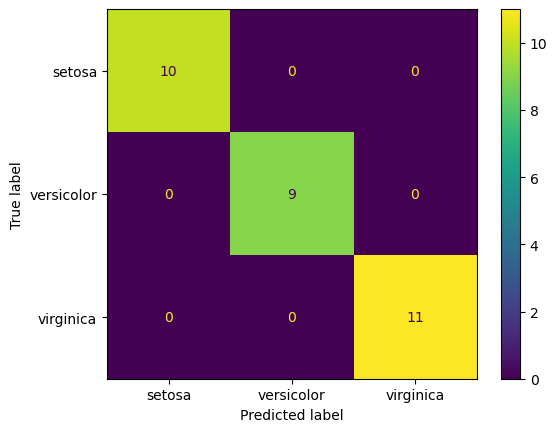

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)
plt.show()

Task 4: Visualizing the Decision Tree


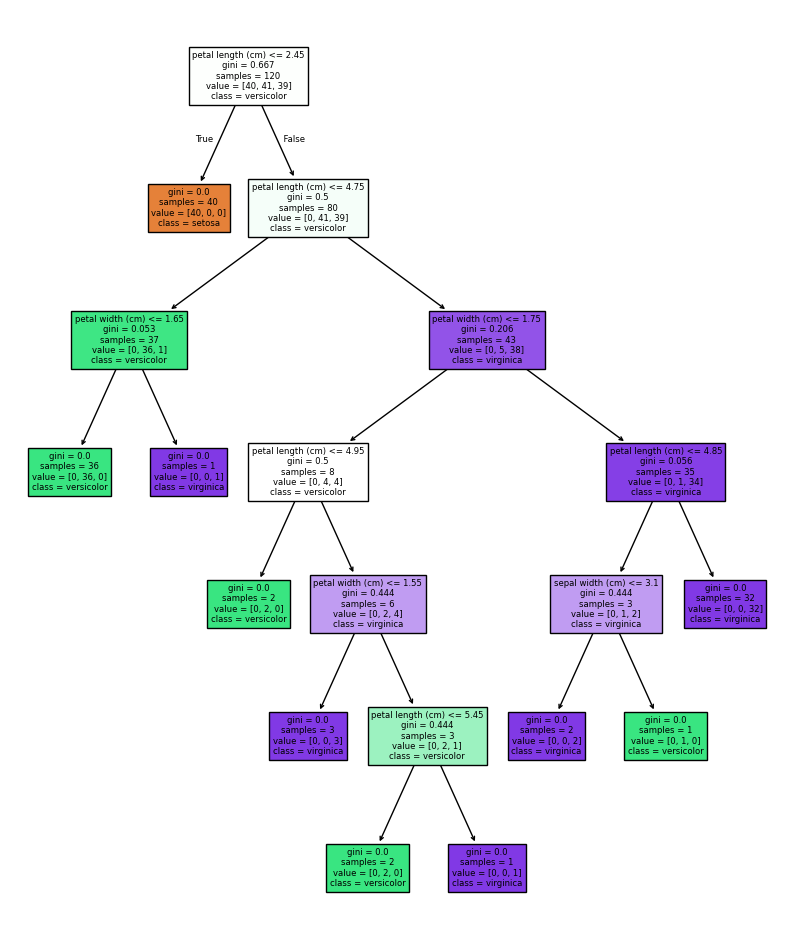

Root node split: petal length (cm) <= 2.450
Number of internal nodes: 9
Number of leaf nodes: 10
Maximum tree depth: 6
Feature selected for root split: petal length (cm)


In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 12))
plot_tree(clf_default, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

tree_ = clf_default.tree_
root_feature = iris.feature_names[tree_.feature[0]]
root_threshold = tree_.threshold[0]
n_leaves = clf_default.get_n_leaves()
n_internal = tree_.node_count - n_leaves
max_depth = clf_default.get_depth()

print(f"Root node split: {root_feature} <= {root_threshold:.3f}")
print(f"Number of internal nodes: {n_internal}")
print(f"Number of leaf nodes: {n_leaves}")
print(f"Maximum tree depth: {max_depth}")
print(f"Feature selected for root split: {root_feature}")

'petal length (cm)' was selected for the root split because it provides the highest information gain (maximum reduction in Gini impurity), perfectly separating setosa (50 samples) from versicolor and virginica in a single split.

Task 5: Comparing Gini Index and Entropy


In [14]:
results_task5 = []
for criterion in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(criterion=criterion, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    depth = clf.get_depth()
    leaves = clf.get_n_leaves()
    root_feat = iris.feature_names[clf.tree_.feature[0]]
    results_task5.append({
        'Criterion': criterion,
        'Accuracy': acc,
        'Tree Depth': depth,
        'Leaf Nodes': leaves,
        'Root Feature': root_feat
    })

df_task5 = pd.DataFrame(results_task5)
df_task5

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,gini,1.0,6,10,petal length (cm)
1,entropy,1.0,6,10,petal length (cm)


Both 'gini' and 'entropy' criteria produced trees with identical complexity (Tree Depth = 6, Leaf Nodes = 10, Testing Accuracy = 1.0) and selected the same root feature ('petal length (cm)'). Neither criterion produced a simpler tree on this dataset.

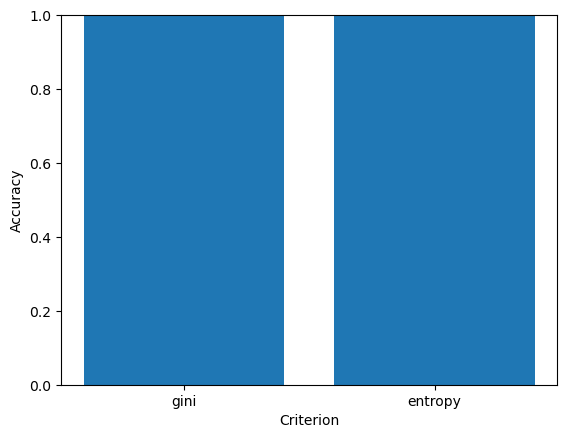

In [30]:
plt.bar(df_task5['Criterion'], df_task5['Accuracy'])
plt.xlabel('Criterion')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

Task 6: Effect of Maximum Tree Depth

In [15]:
results_task6 = []
max_depths = [1, 2, 3, 4, None]
observations_task6 = [
    "Underfitting: Tree depth is too small to capture class boundaries.",
    "Good performance: Captures main split but slightly underfits compared to depth 3.",
    "Best generalization: High testing accuracy with optimal depth.",
    "High accuracy: Slightly deeper tree with full test accuracy.",
    "Full growth: Expands until pure leaves, potential overfitting to noise."
]

for md, obs in zip(max_depths, observations_task6):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()
    results_task6.append({
        'Max Depth': str(md),
        'Training Accuracy': tr_acc,
        'Testing Accuracy': te_acc,
        'Tree Depth': depth,
        'Observation': obs
    })

df_task6 = pd.DataFrame(results_task6)
df_task6

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.675000,0.633333,1,Underfitting: Tree depth is too small to captu...
1,2,0.950000,0.966667,2,Good performance: Captures main split but slig...
2,3,0.958333,1.000000,3,Best generalization: High testing accuracy wit...
3,4,0.975000,1.000000,4,High accuracy: Slightly deeper tree with full ...
4,None,1.000000,1.000000,6,"Full growth: Expands until pure leaves, potent..."


1. Model underfitting: max_depth = 1 is underfitting, as evidenced by low training accuracy (67.50%) and low testing accuracy (63.33%).
2. Model giving best generalization: max_depth = 3 provides the best balance, achieving 100.00% testing accuracy with a low tree depth (3) and minimal training-testing gap (95.83% vs 100.00%).
3. Model most likely to overfit: max_depth = None (and max_depth = 4) is most likely to overfit because it grows to maximum depth (6) achieving 100.00% training accuracy on training noise.

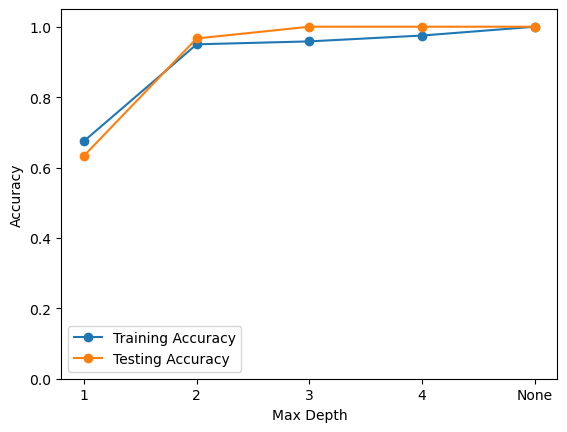

In [27]:
plt.plot(df_task6['Max Depth'], df_task6['Training Accuracy'], marker='o', label='Training Accuracy')
plt.plot(df_task6['Max Depth'], df_task6['Testing Accuracy'], marker='o', label='Testing Accuracy')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

Task 7: Effect of min_samples_split


In [ ]:
results_task7 = []
mss_values = [2, 5, 10, 20]
observations_task7 = [
    "Default parameter; allows splitting down to small nodes, resulting in maximum depth.",
    "Slight pre-pruning; reduces tree depth to 5 and leaf nodes to 8 while retaining 100% accuracy.",
    "Effective pre-pruning; further simplifies tree structure to depth 4 and 6 leaves.",
    "Strong pre-pruning; maintains simple depth 4 tree with 6 leaves and 100% testing accuracy."
]

for mss, obs in zip(mss_values, observations_task7):
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    clf.fit(X_train, y_train)
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()
    leaves = clf.get_n_leaves()
    results_task7.append({
        'min_samples_split': mss,
        'Accuracy': te_acc,
        'Tree Depth': depth,
        'Number of Leaf Nodes': leaves,
        'Observation': obs
    })

df_task7 = pd.DataFrame(results_task7)
df_task7

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,Default parameter; allows splitting down to sm...
1,5,1.0,5,8,Slight pre-pruning; reduces tree depth to 5 an...
2,10,1.0,4,6,Effective pre-pruning; further simplifies tree...
3,20,1.0,4,6,Strong pre-pruning; maintains simple depth 4 t...


Increasing min_samples_split acts as a pre-pruning mechanism by stopping node splits when sample counts are below the threshold. This reduced tree depth from 6 to 4 and leaf nodes from 10 to 6 without degrading testing accuracy (100.00%).


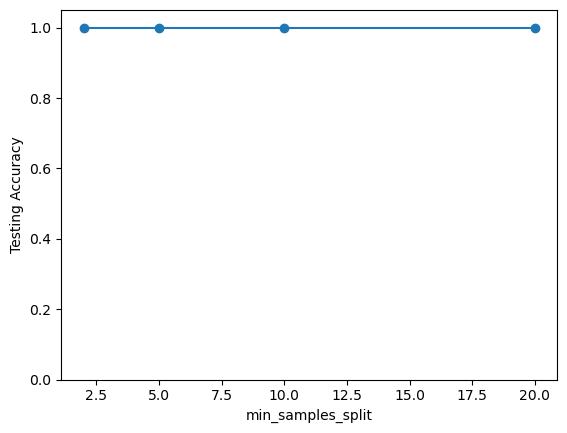

In [28]:
plt.plot(df_task7['min_samples_split'], df_task7['Accuracy'], marker='o')

plt.xlabel('min_samples_split')
plt.ylabel('Testing Accuracy')
plt.ylim(0, 1.05)
plt.show()

Task 8: Effect of min_samples_leaf


In [17]:
results_task8 = []
msl_values = [1, 2, 5, 10]
observations_task8 = [
    "Default unconstrained leaves; results in maximum tree depth (6) and 10 leaf nodes.",
    "Eliminates single-sample leaves; reduces tree depth to 5 and leaf count to 8.",
    "Optimal leaf constraint; reduces tree depth to 4 and leaf count to 6 while maintaining 100% accuracy.",
    "Excessive restriction; maintains depth 4 and 6 leaves but slightly reduces test accuracy to 96.67%."
]

for msl, obs in zip(msl_values, observations_task8):
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()
    leaves = clf.get_n_leaves()
    results_task8.append({
        'min_samples_leaf': msl,
        'Accuracy': te_acc,
        'Tree Depth': depth,
        'Number of Leaf Nodes': leaves,
        'Observation': obs
    })

df_task8 = pd.DataFrame(results_task8)
df_task8


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,Default unconstrained leaves; results in maxim...
1,2,1.000000,5,8,Eliminates single-sample leaves; reduces tree ...
2,5,1.000000,4,6,Optimal leaf constraint; reduces tree depth to...
3,10,0.966667,4,6,Excessive restriction; maintains depth 4 and 6...


Inference: Increasing min_samples_leaf forces leaf nodes to contain more samples, which smooths decision boundaries, reduces tree depth (from 6 to 4) and leaf count (from 10 to 6), and reduces overfitting tendency. However, setting min_samples_leaf too high (e.g., 10) causes slight underfitting (accuracy drops to 96.67%).

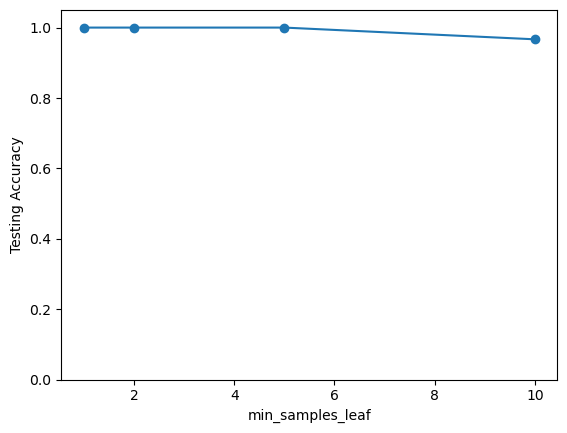

In [29]:
plt.plot(df_task8['min_samples_leaf'], df_task8['Accuracy'], marker='o')

plt.xlabel('min_samples_leaf')
plt.ylabel('Testing Accuracy')
plt.ylim(0, 1.05)
plt.show()

Task 9 

1. Role of the 'criterion' parameter:
   The criterion parameter specifies the mathematical measure used to evaluate the quality of a split at each node. 'gini' uses Gini Impurity (measuring probability of misclassifying a randomly chosen element), whereas 'entropy' uses Information Gain based on Shannon Entropy. Both aim to minimize impurity in child nodes.

2. Influence of 'max_depth' on underfitting and overfitting:
   - Small max_depth (e.g., max_depth=1) restricts the tree from learning complex boundaries, causing underfitting (low train accuracy: 67.50%, low test accuracy: 63.33%).
   - Unrestricted max_depth (max_depth=None) allows the tree to split until all leaves are pure (100.00% train accuracy, depth 6, 10 leaves), increasing the risk of overfitting to training noise.

3. Why larger values of 'min_samples_split' and 'min_samples_leaf' produce simpler trees:
   They serve as pre-pruning hyperparameter constraints. 'min_samples_split' prevents further splitting if an internal node has fewer samples than the threshold, while 'min_samples_leaf' prevents any split that results in a leaf with fewer samples than specified. Both prevent creation of small, highly specific leaf nodes, keeping tree depth low and reducing total leaf nodes.

4. Hyperparameter with the greatest impact on Decision Tree performance:
   'max_depth' had the greatest impact. Restricting max_depth to 1 dropped testing accuracy to 63.33% (underfitting), whereas setting max_depth=3 achieved optimal 100.00% testing accuracy with a simple depth-3 tree. Controlling max_depth directly dictates overall tree structure, depth, and generalization performance.

5. Recommended Decision Tree configuration for the Iris dataset:
   - Recommended Configuration: DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42) or DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
   - Justification: These configurations achieve 100.00% testing accuracy while significantly reducing tree complexity (depth of 3-4 vs 6, and 6 leaf nodes vs 10). They prevent overfitting on training noise without compromising classification performance, offering the best trade-off between simplicity and generalization.